# BSM model with classes + tests 

In this notebook, I focus on implementing the Black-Scholes model using an Object-Oriented approach (Classes). This allows us to encapsulate every operation inside a single block of code, avoiding the hassle of passing multiple parameters to scattered functions.

We also test our model—just as we have done in previous iterations—to ensure it strictly verifies the Put-Call Parity: $C - P = S - K\, e^{-rt}$.

Finally, for completeness, we introduce the analytical computation of the Greeks within our class. With all of this in place, we now have a highly powerful tool capable of pricing and managing the risk of any European option under the BSM framework.

In [1]:
import math as mt
import unittest
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Definition of our class
class BlackScholesModel:
    def __init__(self, S0, K, T, r, sigma):
        self.S0 = float(S0)
        self.K = float(K)
        self.T = float(T)
        self.r = float(r)
        self.sigma = float(sigma)

    def _n_cdf(self, x):
        return 0.5 * (1.0 + mt.erf(x / mt.sqrt(2.0)))
        
    def phi(self, x):
        """Probability Density Function (PDF) of standard normal."""
        return mt.exp(-0.5 * x**2) / mt.sqrt(2.0 * mt.pi)
     

    def calculate_price(self, option_type="call"):
        if self.T <= 0:
            return max(0.0, self.S0 - self.K) if option_type == "call" else max(0.0, self.K - self.S0)

        d1 = (mt.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * mt.sqrt(self.T))
        d2 = d1 - self.sigma * mt.sqrt(self.T)

        if option_type.lower() == "call":
            return self.S0 * self._n_cdf(d1) - self.K * mt.exp(-self.r * self.T) * self._n_cdf(d2)
        elif option_type.lower() == "put":
            return self.K * mt.exp(-self.r * self.T) * self._n_cdf(-d2) - self.S0 * self._n_cdf(-d1)
            
    def get_greeks(self, option_type='call'):
        """
        Calculates the analytical Greeks for European options using the BSM model.
        Optimized to minimize branching and redundant calculations.
        """
        # Standard BSM distance parameters
        d1 = (mt.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * mt.sqrt(self.T))
        d2 = d1 - self.sigma * mt.sqrt(self.T)
        
        # Common term for Theta and Gamma
        pdf_d1 = self.phi(d1)
        theta_term1 = -(self.S0 * pdf_d1 * self.sigma) / (2 * mt.sqrt(self.T))
        
        # Option-type dependent Greeks (Delta, Theta, Rho)
        if option_type == 'call':
            delta = self._n_cdf(d1)
            theta = theta_term1 - self.r * self.K * mt.exp(-self.r * self.T) * self._n_cdf(d2)
            rho = (self.K * self.T * mt.exp(-self.r * self.T) * self._n_cdf(d2)) / 100.0
        else:
            delta = self._n_cdf(d1) - 1.0
            theta = theta_term1 + self.r * self.K * mt.exp(-self.r * self.T) * self._n_cdf(-d2)
            rho = (-self.K * self.T * mt.exp(-self.r * self.T) * self._n_cdf(-d2)) / 100.0
            
        # Option-type independent Greeks (Gamma, Vega)
        # Gamma: Sensitivity of Delta to underlying price changes (Curvature)
        gamma = pdf_d1 / (self.S0 * self.sigma * mt.sqrt(self.T))
        
        # Vega: Sensitivity to a 1% change in implied volatility
        vega = (self.S0 * mt.sqrt(self.T) * pdf_d1) / 100.0
    
        # Daily Theta (Time decay per day)
        theta_day = theta / 365.0
            
        return {
            "Delta": delta,
            "Gamma": gamma,
            "Vega (1%)": vega,
            "Theta (Day)": theta_day,
            "Rho (1%)": rho
        }

In [3]:
class TestBS(unittest.TestCase):
    def test_parity(self):
        model = BlackScholesModel(100, 105, 1, 0.03, 0.2)
        c = model.calculate_price("call")
        p = model.calculate_price("put")
        # C - P = S - K*exp(-rt)
        self.assertAlmostEqual(c - p, 100 - 105*mt.exp(-0.03 * 1), places=5)

suite = unittest.TestLoader().loadTestsFromTestCase(TestBS)
unittest.TextTestRunner(verbosity=2).run(suite)

test_parity (__main__.TestBS.test_parity) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


<unittest.runner.TextTestResult run=1 errors=0 failures=0>

As we can see, the put-call parity condition is satisfied, meaning that our model was correctly implemented. We now proceed to extract some data from our class in order to visualize the pricing dynamics.

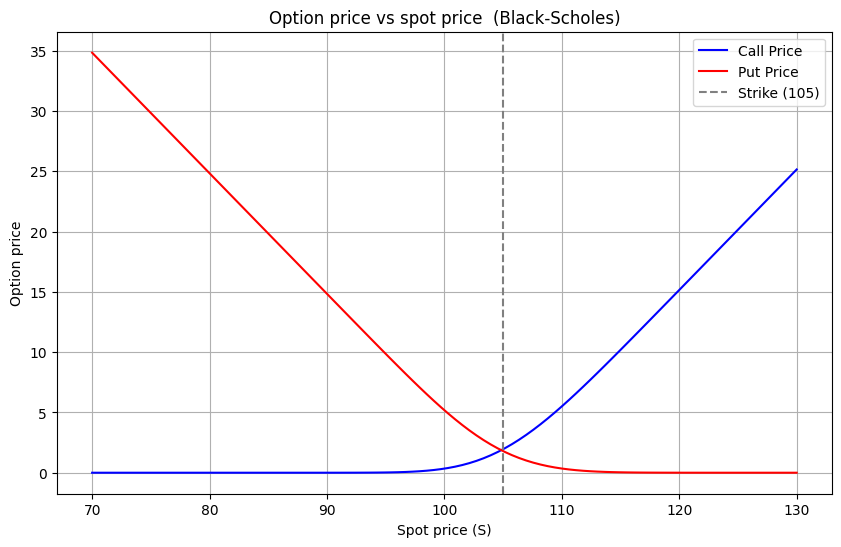

In [4]:
# Generate our data 
precios_spot = np.linspace(70, 130, 100)
calls = [BlackScholesModel(s, 105, 0.05, 0.03, 0.2).calculate_price("call") for s in precios_spot]
puts = [BlackScholesModel(s, 105, 0.05, 0.03, 0.2).calculate_price("put") for s in precios_spot]

plt.figure(figsize=(10, 6))
plt.plot(precios_spot, calls, label='Call Price', color='blue')
plt.plot(precios_spot, puts, label='Put Price', color='red')
plt.axvline(x=105, color='gray', linestyle='--', label='Strike (105)')
plt.title('Option price vs spot price  (Black-Scholes)')
plt.xlabel('Spot price (S)')
plt.ylabel('Option price')
plt.legend()
plt.grid(True)
plt.show()

Due to the short time to maturity (T = 0.05), the option's time value is minimal. As a result, the price curve sharply follows its intrinsic value, meaning that small movements in the spot price around the strike lead to rapid and sharp changes in the option price.

Finally, as I mentioned earlier, we can compute the values of our Greeks. For example, if we wanted to explore the dynamics behind Delta and Gamma, it is as easy as calling our class and retrieving the values we need. The results are presented below:

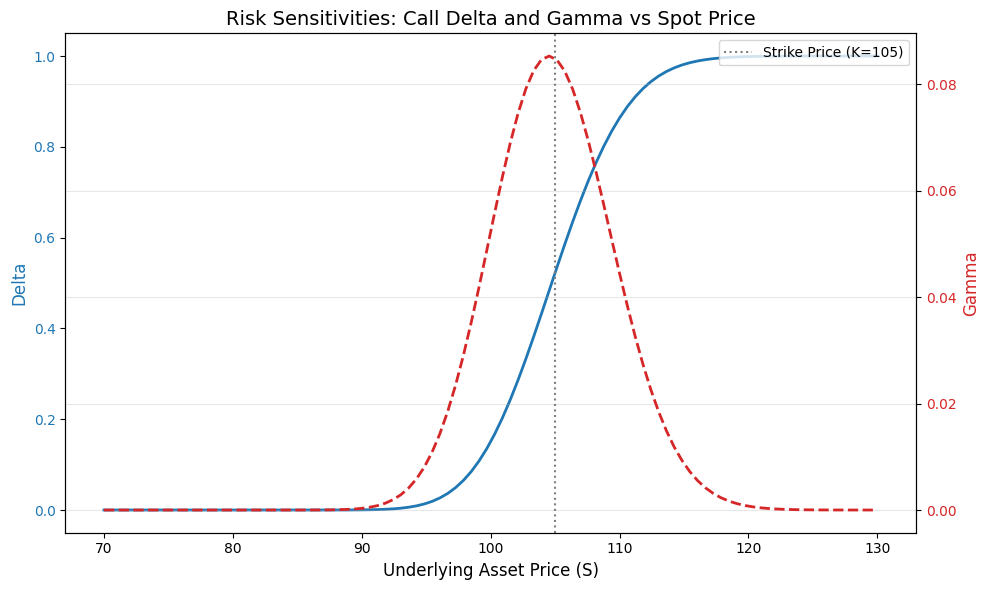

In [5]:
precios_spot = np.linspace(70, 130, 100)
deltas = [BlackScholesModel(s, 105, 0.05, 0.03, 0.2).get_greeks("call").get("Delta") for s in precios_spot]
gammas = [BlackScholesModel(s, 105, 0.05, 0.03, 0.2).get_greeks("put").get("Gamma") for s in precios_spot]

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-axis (Delta)
color = 'tab:blue'
ax1.set_xlabel('Underlying Asset Price (S)', fontsize=12)
ax1.set_ylabel('Delta', color=color, fontsize=12)
ax1.plot(precios_spot, deltas, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Right Y-axis (Gamma)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Gamma', color=color, fontsize=12)
ax2.plot(precios_spot, gammas, color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Vertical line at Strike
plt.axvline(x=105, color='gray', linestyle=':', label=f'Strike Price (K={105})')
plt.title('Risk Sensitivities: Call Delta and Gamma vs Spot Price', fontsize=14)

plt.legend()
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()